#HW 4: Quick Sort

- Please disable code autocomplete by uncheck "Show context-powered code completions" in Tools -> Settings -> Editor.

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt
import random

##Implement Quick Sort
- Naive method (always picks the first element)
- Randomized QuickSort

In [11]:
# QuickSort with different methods to select pivot
# Please refer to Sections 5.2, 5.3, and 5.4

def QuickSort(array, l, r, ChoosePivot):
    if l < r:
        pivot_idx = ChoosePivot(l, r)
        array[pivot_idx], array[r] = array[r], array[pivot_idx]
        pi = Partition(array, l, r)

        QuickSort(array, l, pi - 1, ChoosePivot)
        QuickSort(array, pi + 1, r, ChoosePivot)

def Partition(array, l, r):
    pivot = array[r]
    i = l - 1
    for j in range(l, r):
        if array[j] <= pivot:
            i += 1
            array[i], array[j] = array[j], array[i] # swap to the left, swap to the right!
    array[i + 1], array[r] = array[r], array[i + 1] # crisscross!
    return i + 1 # cha-cha real smooth

def ChoosePivotNaive(l, r):
    return r

def ChoosePivotRandomized(l, r):
    return random.randint(l, r)

# Help function for testing
def IsSorted(array):
    for i in range(len(array)-1):
        if array[i] > array[i+1]:
            return False

    return True

In [12]:
# Quick test on some input arrays
testCases = [[1, 2, 3, 4, 5],
             [2, 1, 4, 3, 5],
             [3, 2, 1, 5, 4],
             [5, 4, 3, 2, 1],
             [3, 3, 5, 1, 2]]

print("Naive method to choose pivot:")
for testCase in testCases:
    print(testCase)
    QuickSort(testCase, 0, len(testCase)-1, ChoosePivotNaive)
    print(testCase)
    print(IsSorted(testCase))

print("Randomized QuickSort:")
for testCase in testCases:
    print(testCase)
    QuickSort(testCase, 0, len(testCase)-1, ChoosePivotRandomized)
    print(testCase)
    print(IsSorted(testCase))

Naive method to choose pivot:
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[2, 1, 4, 3, 5]
[1, 2, 3, 4, 5]
True
[3, 2, 1, 5, 4]
[1, 2, 3, 4, 5]
True
[5, 4, 3, 2, 1]
[1, 2, 3, 4, 5]
True
[3, 3, 5, 1, 2]
[1, 2, 3, 3, 5]
True
Randomized QuickSort:
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[1, 2, 3, 3, 5]
[1, 2, 3, 3, 5]
True


##Compare Randomized QuickSort with MergeSort

In [13]:
# Implement MergeSort

# Implement Merge Sort
# Refer to Merge Sort described in Chapter 1.4 in Textbook

def MergeSort(array):
    if len(array) == 1:
        return array
    else:
        left = MergeSort(array[:len(array)//2])
        right = MergeSort(array[len(array)//2:])
        return Merge(left, right)

def Merge(left, right):
    result = []
    i = 0
    j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result


In [14]:
# Quick test on some input arrays for MergeSort
testCases = [[1, 2, 3, 4, 5],
             [2, 1, 4, 3, 5],
             [3, 2, 1, 5, 4],
             [5, 4, 3, 2, 1],
             [3, 3, 5, 1, 2]]

for testCase in testCases:
    print(testCase)
    output = MergeSort(testCase)
    print(output)
    print(IsSorted(output))

[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[2, 1, 4, 3, 5]
[1, 2, 3, 4, 5]
True
[3, 2, 1, 5, 4]
[1, 2, 3, 4, 5]
True
[5, 4, 3, 2, 1]
[1, 2, 3, 4, 5]
True
[3, 3, 5, 1, 2]
[1, 2, 3, 3, 5]
True


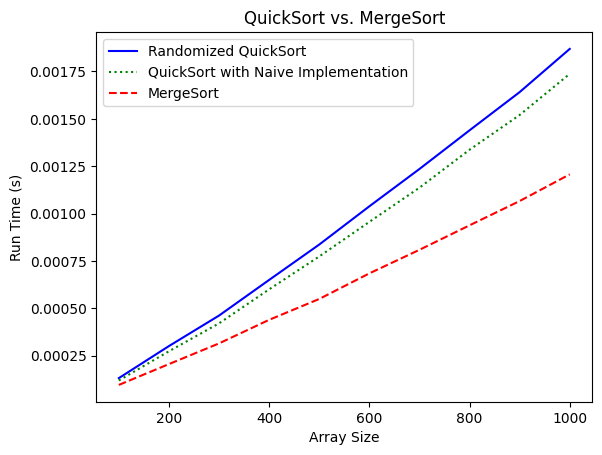

In [16]:
maxNumber = 20000
startArraySize = 100
endArraySize = 1000
stepArraySize = 100
runsPerSize = 1000

# Generate a random array of a given size
def GenerateRandomArray(size):
    return np.random.randint(0, maxNumber, size)

averageRunTimesRandomizedQuickSort = []
averageRunTimesQuickSortNaive = []
averageRunTimesMergeSort = []

np.random.seed(42)

for arraySize in range(startArraySize, endArraySize+1, stepArraySize):
    runTimesRandomizedQuickSort = []
    runTimesQuickSortNaive = []
    runTimesMergeSort = []

    for run in range(runsPerSize):
        array = GenerateRandomArray(arraySize)
        backup_array_1 = array.copy()
        backup_array_2 = array.copy()
        backup_array_3 = array.copy()

        start = time.time()
        resultMergeSort = MergeSort(backup_array_1)
        end = time.time()
        runTimesMergeSort.append(end-start)

        start = time.time()
        QuickSort(backup_array_2, 0, len(backup_array_2)-1, ChoosePivotRandomized)
        end = time.time()
        runTimesRandomizedQuickSort.append(end-start)

        start = time.time()
        QuickSort(backup_array_3, 0, len(backup_array_3)-1, ChoosePivotNaive)
        end = time.time()
        runTimesQuickSortNaive.append(end-start)

        if not IsSorted(backup_array_2):
            print("Error: Randomized QuickSort not correct")
            print("Original Array: ", array)
            print("QuickSort: ", backup_array_2)
            print("MergeSort: ", resultMergeSort)
            break

    averageRunTimesRandomizedQuickSort.append(np.mean(runTimesRandomizedQuickSort))
    averageRunTimesQuickSortNaive.append(np.mean(runTimesQuickSortNaive))
    averageRunTimesMergeSort.append(np.mean(runTimesMergeSort))

x = np.arange(startArraySize, endArraySize+1, stepArraySize)
plt.plot(x, averageRunTimesRandomizedQuickSort, 'b', label='Randomized QuickSort')
plt.plot(x, averageRunTimesQuickSortNaive, 'g:', label='QuickSort with Naive Implementation')
plt.plot(x, averageRunTimesMergeSort, 'r--', label='MergeSort')
plt.title('QuickSort vs. MergeSort')
plt.xlabel('Array Size')
plt.ylabel('Run Time (s)')
plt.legend()
plt.show()
